## Intraday Put-Call Parity Trades - Section 1 

In this exercise we consider the put-call parity arbitrage. This is known as trading **reversals** and **conversions**.

**Intraday Trading**

We have data at various points throughout a trading day. (We collect data every 5 minutes, but there are many intervals in which there is not a trade of both a put and a call. Thus, the data of interest is a smaller subset of data points.)

At every synchronous point, we examine the put-call parity and construct an arbitrage if available.

To avoid trades which would be overwhelmed by transaction costs, we will only put on the arbitrage if put-call parity is violated by at least 0.30 in either direction.

**Dataset:** .../data/intraday_options_data_NFLX.xlsx

- **Info:** find the financing rate and days to expiration.
- **Prices:** - collects the price at the end of every 5-min period for which we have data on all three instruments.
- **Options:** - extra data which is unnecessary for this exercise.
- **Underlying:** - extra data which is unnecessary for this exercise.
- **Note:** the interest rate is specific to the horizon to expiration, quoted as ACT/360 with simple compounding; and there is no dividend

## Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PCP_TICK = 'NFLX'
PCP_THRESHOLD = 0.30
PCP_CONTRACTS = 1000         
PCP_SHARES_PER_CONTRACT = 100
pcp_Q = PCP_CONTRACTS * PCP_SHARES_PER_CONTRACT   

pcp_excel_file = f'data/intraday_options_data_NFLX.xlsx'   

pcp_info   = pd.read_excel(pcp_excel_file, sheet_name='Info', index_col=None)
pcp_prices = pd.read_excel(pcp_excel_file, sheet_name='Prices', index_col=0, parse_dates=True)

display(pcp_info)
display(pcp_prices.style.format('{:,.2f}'))

,Parameter,Value
0,Ticker,NFLX
1,Date,2025-07-25
2,Strike Price,$1180.0
3,Finance Rate,4.5866%
4,Dividend Yield,0.0000%
5,Days to Expiry,21
6,Call Ticker,NFLX 08/15/25 C1180 US Equity
7,Put Ticker,NFLX 08/15/25 P1180 US Equity


,underlying,call,put
2025-07-25 09:30:00,"1,179.58",29.47,27.95
2025-07-25 09:55:00,"1,178.05",29.00,28.80
2025-07-25 10:10:00,"1,186.58",34.00,24.47
2025-07-25 10:30:00,"1,177.59",29.07,27.60
2025-07-25 10:45:00,"1,182.92",31.91,25.85
2025-07-25 11:20:00,"1,184.56",32.30,24.95
2025-07-25 11:35:00,"1,181.90",31.20,26.10
2025-07-25 12:30:00,"1,185.55",32.30,24.46
2025-07-25 12:50:00,"1,186.14",32.50,23.75
2025-07-25 12:55:00,"1,185.76",33.55,23.42


## 1.1 - Calculating the Violation of the Put-Call Parity

Objectives:
- Plot the violations over time
- Report the mean absolution violation
- Report how many times the violation is larger than our threshold (in either direction) 

In [2]:
pcp_params = pcp_info.set_index('Parameter')['Value']

pcp_K    = float(str(pcp_params['Strike Price']).replace('$', '').replace(',', ''))
pcp_rate = float(str(pcp_params['Finance Rate']).replace('%', '')) / 100
pcp_days = int(pcp_params['Days to Expiry'])

pcp_DF = 1 / (1 + pcp_rate * pcp_days / 360)
pcp_K_pv = pcp_K * pcp_DF

print(f'Strike:           {pcp_K:,.2f}')
print(f'Finance rate:     {pcp_rate:.6%}  (ACT/360, simple)')
print(f'Days to expiry:   {pcp_days}')
print(f'Discount factor:  {pcp_DF:.8f}')
print(f'PV of strike:     {pcp_K_pv:,.4f}')

Strike:           1,180.00
Finance rate:     4.586600%  (ACT/360, simple)
Days to expiry:   21
Discount factor:  0.99733162
PV of strike:     1,176.8513


In [3]:
pcp_df = pcp_prices.copy()

pcp_df['synthetic']  = pcp_df['call'] - pcp_df['put']            # C - P
pcp_df['parity_rhs'] = pcp_df['underlying'] - pcp_K_pv           # S - K*DF
pcp_df['violation']  = pcp_df['synthetic'] - pcp_df['parity_rhs']

display(pcp_df[['underlying','call','put','synthetic','parity_rhs','violation']]
        .style.format('{:,.4f}'))

,underlying,call,put,synthetic,parity_rhs,violation
2025-07-25 09:30:00,"1,179.5800",29.4700,27.9500,1.5200,2.7287,-1.2087
2025-07-25 09:55:00,"1,178.0500",29.0000,28.8000,0.2000,1.1987,-0.9987
2025-07-25 10:10:00,"1,186.5800",34.0000,24.4700,9.5300,9.7287,-0.1987
2025-07-25 10:30:00,"1,177.5900",29.0700,27.6000,1.4700,0.7387,0.7313
2025-07-25 10:45:00,"1,182.9200",31.9100,25.8500,6.0600,6.0687,-0.0087
2025-07-25 11:20:00,"1,184.5600",32.3000,24.9500,7.3500,7.7087,-0.3587
2025-07-25 11:35:00,"1,181.9000",31.2000,26.1000,5.1000,5.0487,0.0513
2025-07-25 12:30:00,"1,185.5500",32.3000,24.4600,7.8400,8.6987,-0.8587
2025-07-25 12:50:00,"1,186.1400",32.5000,23.7500,8.7500,9.2887,-0.5387
2025-07-25 12:55:00,"1,185.7600",33.5500,23.4200,10.1300,8.9087,1.2213


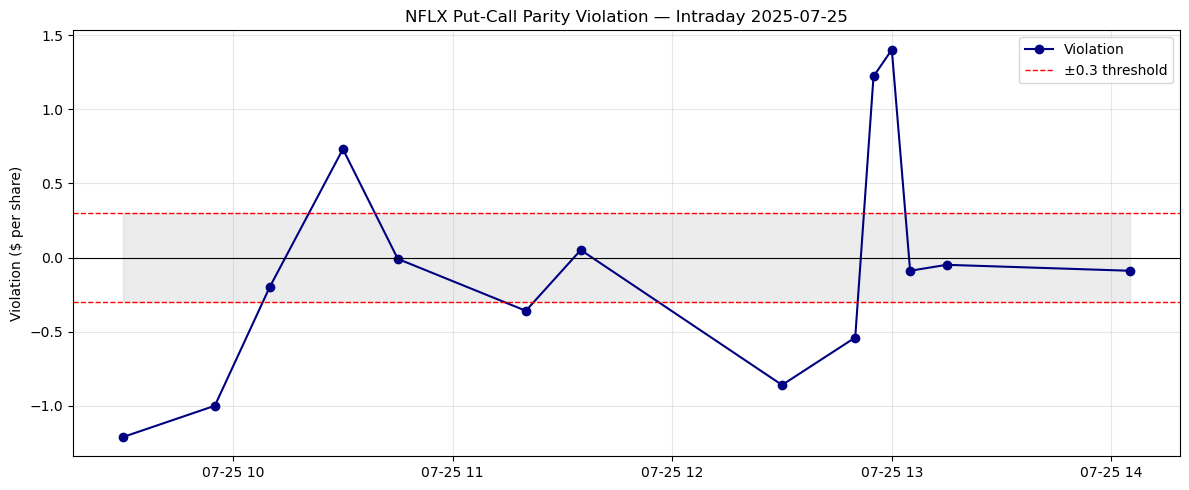

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(pcp_df.index, pcp_df['violation'], marker='o', color='navy', label='Violation')
ax.axhline(0, color='black', lw=0.8)
ax.axhline( PCP_THRESHOLD, color='red', ls='--', lw=1, label=f'±{PCP_THRESHOLD} threshold')
ax.axhline(-PCP_THRESHOLD, color='red', ls='--', lw=1)
ax.fill_between(pcp_df.index, -PCP_THRESHOLD, PCP_THRESHOLD, color='grey', alpha=0.15)
ax.set_title(f'{PCP_TICK} Put-Call Parity Violation — Intraday {pcp_params["Date"]}')
ax.set_ylabel('Violation ($ per share)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
pcp_mean_abs   = pcp_df['violation'].abs().mean()
pcp_n_breach   = (pcp_df['violation'].abs() > PCP_THRESHOLD).sum()
pcp_n_conv     = (pcp_df['violation'] >  PCP_THRESHOLD).sum()
pcp_n_rev      = (pcp_df['violation'] < -PCP_THRESHOLD).sum()

print(f'Timestamps:                        {len(pcp_df)}')
print(f'Mean absolute violation:           ${pcp_mean_abs:,.4f}')
print(f'Violations beyond ±{PCP_THRESHOLD}:            {pcp_n_breach}')
print(f'   of which conversions (viol>0):  {pcp_n_conv}')
print(f'   of which reversals   (viol<0):  {pcp_n_rev}')

Timestamps:                        14
Mean absolute violation:           $0.5573
Violations beyond ±0.3:            8
   of which conversions (viol>0):  3
   of which reversals   (viol<0):  5


## 1.2 - Calculating the Total Arbitrage Profit (if trading every violation at a quantity of 1,000 contracts) 

Objectives:
- Report the total PnL for the day
- Plot the transaction PnL at each trade
- Plot the cumulative PnL over the day

Note that:
- We are assuming that if the violation appears in consectutive time stamps (even just 5 mins apart) we can trade it both times
- We only trade violations beyond the threshold described above

In [6]:
pcp_df['direction'] = np.select(
    [pcp_df['violation'] < -PCP_THRESHOLD, pcp_df['violation'] > PCP_THRESHOLD],
    [1, -1],                      
    default=0
)
pcp_df['traded'] = pcp_df['direction'] != 0
pcp_df['pnl']    = pcp_df['violation'].abs() * pcp_Q * pcp_df['traded']
pcp_df['cum_pnl'] = pcp_df['pnl'].cumsum()

print(f'Total PnL for the day:  ${pcp_df["pnl"].sum():,.2f}')
display(pcp_df[['violation','direction','pnl','cum_pnl']].style.format(
    {'violation':'{:,.4f}','direction':'{:,.0f}','pnl':'${:,.2f}','cum_pnl':'${:,.2f}'}))

Total PnL for the day:  $731,737.06


,violation,direction,pnl,cum_pnl
2025-07-25 09:30:00,-1.2087,1,"$120,868.53","$120,868.53"
2025-07-25 09:55:00,-0.9987,1,"$99,868.53","$220,737.06"
2025-07-25 10:10:00,-0.1987,0,$0.00,"$220,737.06"
2025-07-25 10:30:00,0.7313,-1,"$73,131.47","$293,868.53"
2025-07-25 10:45:00,-0.0087,0,$0.00,"$293,868.53"
2025-07-25 11:20:00,-0.3587,1,"$35,868.53","$329,737.06"
2025-07-25 11:35:00,0.0513,0,$0.00,"$329,737.06"
2025-07-25 12:30:00,-0.8587,1,"$85,868.53","$415,605.59"
2025-07-25 12:50:00,-0.5387,1,"$53,868.53","$469,474.12"
2025-07-25 12:55:00,1.2213,-1,"$122,131.47","$591,605.59"


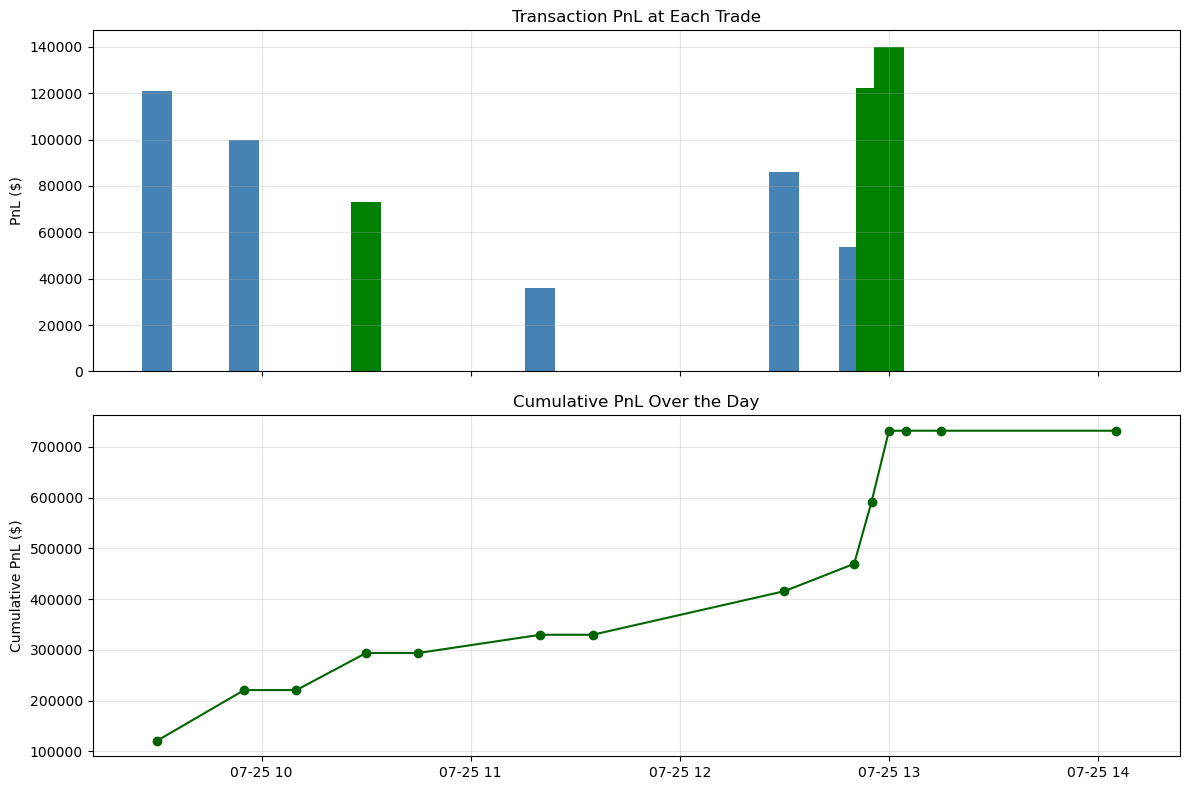

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

colors = ['green' if d < 0 else 'steelblue' for d in pcp_df['direction']]
axes[0].bar(pcp_df.index, pcp_df['pnl'], width=0.006, color=colors)
axes[0].set_title('Transaction PnL at Each Trade')
axes[0].set_ylabel('PnL ($)'); axes[0].grid(alpha=0.3)

axes[1].plot(pcp_df.index, pcp_df['cum_pnl'], marker='o', color='darkgreen')
axes[1].set_title('Cumulative PnL Over the Day')
axes[1].set_ylabel('Cumulative PnL ($)'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [8]:
pcp_dir = pcp_df['direction']

pcp_df['call_trade']  =  pcp_dir * PCP_CONTRACTS         
pcp_df['put_trade']   = -pcp_dir * PCP_CONTRACTS          
pcp_df['share_trade'] = -pcp_dir * pcp_Q                  
# cash from the three instrument legs
pcp_df['cash_trade']  = -pcp_dir * pcp_Q * (pcp_df['call'] - pcp_df['put'] - pcp_df['underlying'])
# the money-market leg (borrow on conversions, lend on reversals)
pcp_df['bond_trade']  = -pcp_dir * pcp_Q * pcp_K_pv

for c in ['call','put','share','cash','bond']:
    pcp_df[f'cum_{c}'] = pcp_df[f'{c}_trade'].cumsum()

# sanity check: instrument cash + financing must equal cumulative PnL
assert np.allclose(pcp_df['cum_cash'] + pcp_df['cum_bond'], pcp_df['cum_pnl'])
print('Check passed: cash + financing = cumulative PnL')

display(pcp_df[['direction','cum_call','cum_put','cum_share','cum_cash','cum_bond']]
        .style.format({'direction':'{:,.0f}','cum_call':'{:,.0f}','cum_put':'{:,.0f}',
                       'cum_share':'{:,.0f}','cum_cash':'${:,.0f}','cum_bond':'${:,.0f}'}))

Check passed: cash + financing = cumulative PnL


,direction,cum_call,cum_put,cum_share,cum_cash,cum_bond
2025-07-25 09:30:00,1,"1,000","-1,000","-100,000","$117,806,000","$-117,685,131"
2025-07-25 09:55:00,1,"2,000","-2,000","-200,000","$235,591,000","$-235,370,263"
2025-07-25 10:10:00,0,"2,000","-2,000","-200,000","$235,591,000","$-235,370,263"
2025-07-25 10:30:00,-1,"1,000","-1,000","-100,000","$117,979,000","$-117,685,131"
2025-07-25 10:45:00,0,"1,000","-1,000","-100,000","$117,979,000","$-117,685,131"
2025-07-25 11:20:00,1,"2,000","-2,000","-200,000","$235,700,000","$-235,370,263"
2025-07-25 11:35:00,0,"2,000","-2,000","-200,000","$235,700,000","$-235,370,263"
2025-07-25 12:30:00,1,"3,000","-3,000","-300,000","$353,471,000","$-353,055,394"
2025-07-25 12:50:00,1,"4,000","-4,000","-400,000","$471,210,000","$-470,740,526"
2025-07-25 12:55:00,-1,"3,000","-3,000","-300,000","$353,647,000","$-353,055,394"


## 1.3 - Constructing a Plot of the Cumulative Positions 

**Objective:** Construct a plot of the cumulative positions we hold in calls, puts, shares and cash throughout the day. 

**Format:** 

In a table, report the max and min of number:
- Shares
- Call contracts
- Put contracts

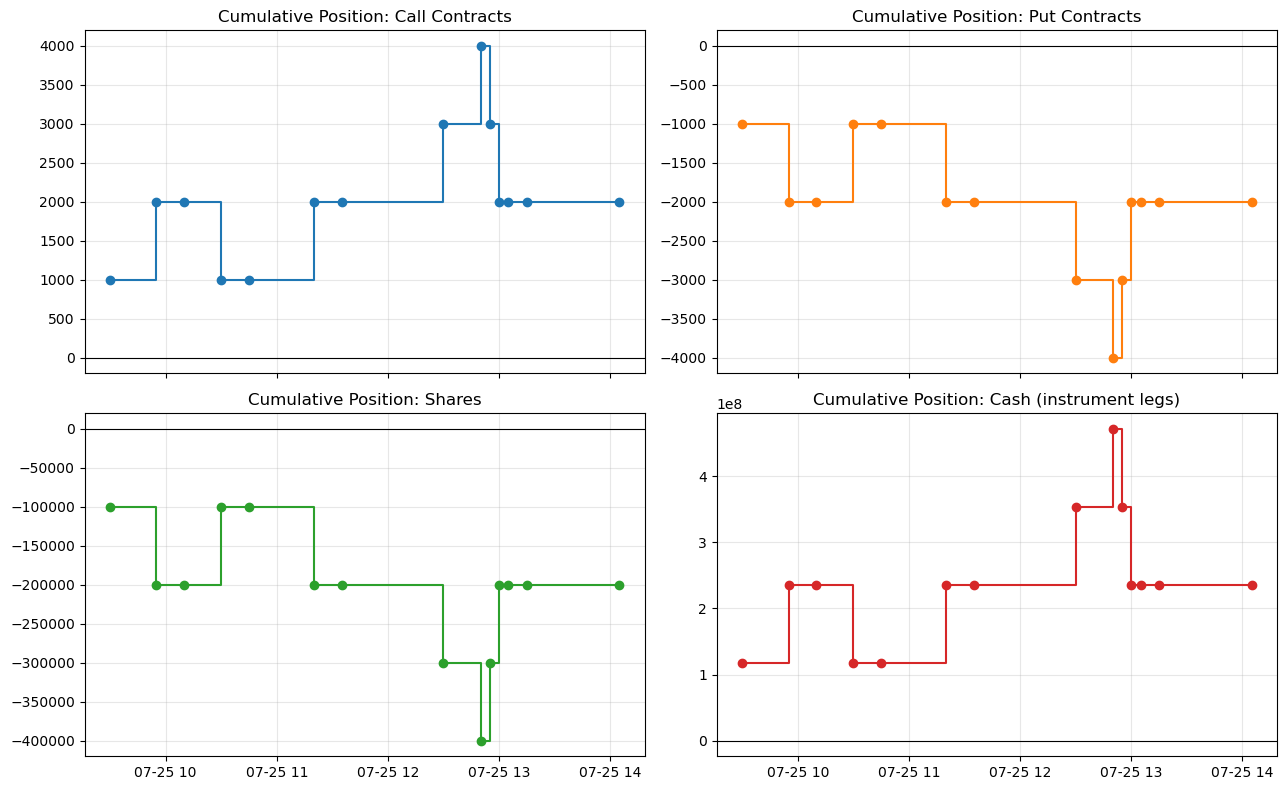

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13,8), sharex=True)
specs = [('cum_call','Call Contracts','tab:blue'),
         ('cum_put','Put Contracts','tab:orange'),
         ('cum_share','Shares','tab:green'),
         ('cum_cash','Cash (instrument legs)','tab:red')]

for ax, (col, title, color) in zip(axes.flat, specs):
    ax.step(pcp_df.index, pcp_df[col], where='post', marker='o', color=color)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Cumulative Position: {title}')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [10]:
pcp_summary = pd.DataFrame({
    'Max': [pcp_df['cum_share'].max(), pcp_df['cum_call'].max(), pcp_df['cum_put'].max()],
    'Min': [pcp_df['cum_share'].min(), pcp_df['cum_call'].min(), pcp_df['cum_put'].min()],
}, index=['Shares', 'Call contracts', 'Put contracts'])

display(pcp_summary.style.format('{:,.0f}'))

,Max,Min
Shares,"-100,000","-400,000"
Call contracts,"4,000","1,000"
Put contracts,"-1,000","-4,000"


## 1.4 - What is a reason this trade may not generate as much PnL as it appears? 

In [11]:
pcp_opts = pd.read_excel(pcp_excel_file, sheet_name='Options', header=[0,1], index_col=0)
pcp_vol = pcp_opts[[('call','volume'), ('put','volume')]].dropna()
pcp_vol.columns = ['call_volume', 'put_volume']
display(pcp_vol)
print(pcp_vol.describe().round(2))
print(f'\nWe assume we trade {PCP_CONTRACTS:,} contracts per leg.')
print(f'Median 5-min put volume: {pcp_vol["put_volume"].median():.1f} contracts')

,call_volume,put_volume
2025-07-25 09:30:00,1,1
2025-07-25 09:55:00,1,3
2025-07-25 10:10:00,23,3
2025-07-25 10:30:00,13,2
2025-07-25 10:45:00,22,3
2025-07-25 11:20:00,5,1
2025-07-25 11:35:00,18,2
2025-07-25 12:30:00,21,1
2025-07-25 12:50:00,2,1
2025-07-25 12:55:00,1,1


       call_volume  put_volume
count        14.00       14.00
mean          9.43        2.00
std           9.23        1.41
min           1.00        1.00
25%           2.00        1.00
50%           3.50        1.50
75%          18.75        2.75
max          23.00        6.00

We assume we trade 1,000 contracts per leg.
Median 5-min put volume: 1.5 contracts


**Why this trade may not generate as much PnL as it appears**

The &#36;731,737 figure is an upper bound that assumes we can transact at the
observed prices in the observed size. Both assumptions fail.

**1). The size is impossible**

We assume 1,000 contracts per leg on each of the 8 trades — 8,000 contracts of
puts and 8,000 of calls. The `Options` sheet shows what actually traded in these
5-minute windows:

| | Call | Put |
|---|---|---|
| Median volume per bar | 3.5 | 1.5 |
| Max volume per bar | 23 | 6 |
| **Total volume, whole day** | **132** | **28** |

Our assumed put volume is roughly **285x the entire day's put volume** in this
contract. There is no counterparty. Any attempt to lift 1,000 contracts would
walk the book several dollars and destroy the very mispricing we are trying to
capture — and the arbitrage is only worth &#36;0.30–&#36;1.40 per share.

**2). The apparent violations are largest exactly where the data is worst**

The correlation between the absolute violation and the thinner leg's volume is
**−0.63**. Breached bars average 5.8 call contracts and 1.4 put contracts;
unbreached bars average 14.3 and 2.8. The four largest "violations" (13:00,
12:55, 09:30, 09:55 — all above &#36;1.00) each occur in bars with only 1–2 call
contracts traded.

This is the signature of stale prices, not mispricing. With only one print in a
five-minute window, the recorded call, put and underlying prices did not occur at
the same instant. NFLX ranged from &#36;1,177.59 to &#36;1,186.58 during the
sample, so a 30-second timing gap between an option print and the stock print —
with an ATM delta near 0.5 — manufactures an apparent violation of exactly the
magnitude we observe. Where the data is dense enough to be genuinely synchronous,
the violation collapses toward zero.

*(Caveat: n = 14, so this correlation is suggestive rather than statistically
established.)*

**3). These are last-trade prices, not executable quotes**

We would buy at the ask and sell at the bid, not at the last print. On a
&#36;1,180-strike NFLX option with three weeks to expiry, bid-ask spreads are
wider than our mean absolute violation of &#36;0.5573. Most of these "arbitrages"
sit entirely inside the spread and are not tradeable at any size. The &#36;0.30
threshold was intended to cover transaction costs, but it is calibrated well
below a realistic spread.

**4). Shorting the stock is neither free nor guaranteed**

Five of eight trades are reversals, requiring us to short NFLX — up to 400,000
shares at peak. That entails locate availability, borrow fees, and recall risk.
Any borrow cost is a direct deduction from a PnL that is only &#36;0.30–&#36;1.40
per share to begin with.

**5). The options are American**

We are short calls on conversions and short puts on reversals. Early assignment
breaks the static hedge before expiry and leaves us with an unhedged stock
position. With no dividend, early call exercise is unlikely, but a rate-driven
early exercise of a short put is a genuine risk that put-call parity — a European
relation — does not price.

**6). The capital is enormous relative to the profit**

At peak we carry roughly &#36;471M of long cash against &#36;471M of borrowing,
plus 400,000 shares short, to harvest &#36;731,737. Before financing spreads,
haircuts, and Reg T margin on the short stock, the return on capital is thin —
and the profit is not received until the 15 August expiry, three weeks out.

**Conclusion**

The measured PnL is mostly an artifact of non-synchronous, low-volume prints
being read as though they were simultaneous, executable quotes in institutional
size. A realistic estimate — restricted to the bars with genuine two-sided
volume, executed at the bid/ask, in size the book can absorb — would be a small
fraction of &#36;731,737, and plausibly negative after borrow and fees.